In [182]:
import importlib
import scipy.io
import utils.utils as u 
import utils.preprocessing as p 
import utils.models as m 
import numpy as np
import mne
import polars as pl
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
import random
import matplotlib.pyplot as plt

# Reload modules to reflect recent changes:
importlib.reload(u)
importlib.reload(p)
importlib.reload(m)

SEED=42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [183]:
#Load files from directory of the experiment
files=u.get_file_names("../data", experiment="CLA")
print(files)

['../data/CLA-SubjectA-160108-3St-LRHand.mat', '../data/CLA-SubjectB-151019-3St-LRHand.mat', '../data/CLA-SubjectB-151020-3St-LRHand.mat', '../data/CLA-SubjectB-151215-3St-LRHand.mat', '../data/CLA-SubjectC-151126-3St-LRHand.mat', '../data/CLA-SubjectC-151216-3St-LRHand.mat', '../data/CLA-SubjectC-151223-3St-LRHand.mat', '../data/CLA-SubjectD-151125-3St-LRHand.mat', '../data/CLA-SubjectE-151225-3St-LRHand.mat', '../data/CLA-SubjectE-160119-3St-LRHand.mat', '../data/CLA-SubjectE-160122-3St-LRHand.mat', '../data/CLA-SubjectF-150916-3St-LRHand.mat', '../data/CLA-SubjectF-150917-3St-LRHand.mat', '../data/CLA-SubjectF-150928-3St-LRHand.mat', '../data/CLA-SubjectJ-170504-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170508-3St-LRHand-Inter.mat', '../data/CLA-SubjectJ-170510-3St-LRHand-Inter.mat']


In [184]:
FILE=files[0] #Choose one file for now, later we will loop over all files
mat_data = scipy.io.loadmat(FILE)
print(f"The file includes metadata coming from python that we don't need:{mat_data.keys()}.\n")
print(f"For now we will focus on the 'o' key which contains the EEG data and information about the experiment.\n")

subject_info = ((FILE.split("/")[-1]).split(".")[0]).split("-") #We can extract subject info from the file name
data = mat_data['o'][0, 0]       
print(f"Data keys include:{data.dtype.names}.\n") 
sfreq = int(data['sampFreq'][0, 0]) if data['sampFreq'].size > 0 else 200
eeg_data = data['data'].T  # Shape: (n_channels, n_samples)
channel_names = [
    str(ch[0]).strip("[]' ")
    for ch in data["chnames"]
]
info = mne.create_info(
            ch_names=channel_names,
            sfreq=sfreq,
            ch_types='eeg'
        )
        
info.set_channel_types({"X5": "misc"}) # Set 'X5' as misc type to avoid errors
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)
raw = mne.io.RawArray(eeg_data, info)
print(raw.info)

The file includes metadata coming from python that we don't need:dict_keys(['__header__', '__version__', '__globals__', 'o']).

For now we will focus on the 'o' key which contains the EEG data and information about the experiment.

Data keys include:('id', 'tag', 'sampFreq', 'nS', 'marker', 'data', 'chnames', 'binsuV').

Creating RawArray with float64 data, n_channels=22, n_times=671600
    Range : 0 ... 671599 =      0.000 ...  3357.995 secs
Ready.
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, A1, A2, F7, F8, T3, ...
 chs: 21 EEG, 1 misc
 custom_ref_applied: False
 dig: 24 items (3 Cardinal, 21 EEG)
 highpass: 0.0 Hz
 lowpass: 100.0 Hz
 meas_date: unspecified
 nchan: 22
 projs: []
 sfreq: 200.0 Hz
>


C:\Users\josub\AppData\Local\Temp\ipykernel_18296\1191536505.py:21: RuntimeWarning: The unit for channel(s) X5 has changed from V to NA.
  info.set_channel_types({"X5": "misc"}) # Set 'X5' as misc type to avoid errors


In [185]:
print("The windows and sync is not perfect")
labels = np.array(data['marker'])
import numpy as np
from itertools import groupby
grouped_data = []
for k, g in groupby(labels):
    series_length = len(list(g))
    grouped_data.append((k, series_length))
for marker, length in grouped_data[:10]:
    if marker != 0:  # Only print non-zero markers
        print(f"Marker {marker}: Length {length}")
non_zero_lengths = [length for k, length in grouped_data if k != 0]
if non_zero_lengths:
    print(f"\nMinimum length of a non-zero marker series: {min(non_zero_lengths)}")
    
print("This is not the 170 samples we expected, let's check what is going on")

The windows and sync is not perfect
Marker [3]: Length 203
Marker [3]: Length 203
Marker [1]: Length 203
Marker [1]: Length 204
Marker [2]: Length 203

Minimum length of a non-zero marker series: 202
This is not the 170 samples we expected, let's check what is going on


Sync channel data (first 10 samples): [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
Spike indixes:[1855 1856 1857 1858 1859 1860 1861 1862 3060 3061]
Compute gaps:[   1    1    1    1    1    1    1 1198    1    1]
Indices in gaps:[ 7 18 42 72 73 74 76 78 81 84]
Spike onsets in the plotted window: [100399 101084 101634]


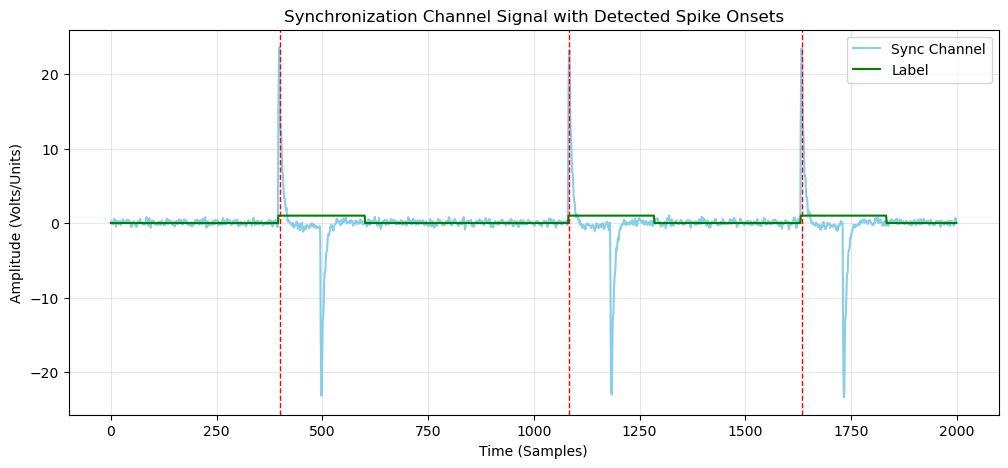

In [187]:
COLOR_MAP = {
    0: 'gray',    # Baseline/Rest
    1: 'blue',    # Mental Imagery 1
    2: 'red',     # Mental Imagery 2
    3: 'green',   # Mental Imagery 3 
}
THRESHOLD=20
sync_data = raw.get_data(picks='X5').flatten()
print(f"Sync channel data (first 10 samples): {sync_data[:10]}")
spikes=np.where(sync_data> 20)[0]
print(f"Spike indixes:{spikes[:10]}")
gaps = np.diff(spikes)
print(f"Compute gaps:{gaps[:10]}")

indices_in_gaps = np.where(gaps > 2)[0]
print(f"Indices in gaps:{indices_in_gaps[:10]}")
first_spike= spikes[0]
subsequent_spikes = spikes[indices_in_gaps]
final_spike_onsets = np.concatenate([[first_spike], subsequent_spikes])


START_OFFSET = 100000
WINDOW= 2000
plt.figure(figsize=(12, 5))
plt.plot(range(WINDOW), sync_data[START_OFFSET: START_OFFSET+WINDOW], label='Sync Channel', color='skyblue')
plt.plot(range(WINDOW), data["marker"][START_OFFSET: START_OFFSET+WINDOW], label='Label', color='green')

spikes_plot = final_spike_onsets[(final_spike_onsets >= START_OFFSET) & (final_spike_onsets < START_OFFSET + WINDOW)]
print(f"Spike onsets in the plotted window: {spikes_plot}")
for onset in spikes_plot:
    # Only label the first vertical line for a clean legend
    plt.axvline(x=onset-START_OFFSET, color='red', linestyle='--', linewidth=1)


plt.title('Synchronization Channel Signal with Detected Spike Onsets')
plt.xlabel('Time (Samples)')
plt.ylabel('Amplitude (Volts/Units)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



The syncronization seems to be right we just need to change the length of the windows to be consistent

In [ ]:
#NOTE THIS WAY WE WILL ALSO HAVE 0 EVENTS
markers_diff = np.diff(data["marker"].squeeze())
print(f"Markers : {data['marker'][:10]}")
print(f"Size of data['marker']: {len(data['marker'])}")
print(f"Print markers_diff (first 10): {markers_diff[:10]}")

event_samples = np.where(markers_diff !=0)
print(f"Event samples (first 10): {event_samples[0][:10]}")
event_count = len(event_samples[0])
print(f"Total Events Found: {event_count}")

# Get event values (your labels)
event_values = data["marker"].squeeze()[event_samples[0]+ 1]
events = np.column_stack([
        event_samples[0]+1, 
        np.zeros(event_count, dtype=int), 
        event_values
    ]).astype(int)

print(f"Events (first 10): {events[:10]}")
    

Markers : [[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]
Size of data['marker']: 671600
Print markers_diff (first 10): [0 0 0 0 0 0 0 0 0 0]
Event samples (first 10): [37271 37474 37782 37985 38369 38572 39021 39225 39554 39757]
Total Events Found: 1920
Events (first 10): [[37272     0     3]
 [37475     0     0]
 [37783     0     3]
 [37986     0     0]
 [38370     0     1]
 [38573     0     0]
 [39022     0     1]
 [39226     0     0]
 [39555     0     2]
 [39758     0     0]]


In [ ]:
eeg_channels = [ch for ch in channel_names if ch not in ['X5','X3']]
# --- Option A: A1-A2 Average Reference ---
raw_a1a2 = raw.copy().set_eeg_reference(ref_channels=['A1', 'A2'])
# --- Option B: Common Average Reference (CAR) ---
# Use the average of all EEG channels defined in the 10-20 configuration
raw_car = raw.copy().set_eeg_reference(ref_channels=eeg_channels)
# --- Option C: Laplace Reference (Surface Laplacian) ---
# In MNE, this is often done by calculating the Surface Laplacian.
raw_laplace = mne.preprocessing.compute_current_source_density(raw.copy().pick("eeg"))

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Fitted sphere radius:         95.6 mm
Origin head coordinates:      -0.9 15.8 45.4 mm
Origin device coordinates:    -0.9 15.8 45.4 mm


In [ ]:
epochs_a1a2 = mne.Epochs(
    raw=raw_a1a2,
    events=events,
    tmin=0,
    tmax=0.85,
    baseline=None,
    preload=True,
    picks=['eeg']
)
epochs_car = mne.Epochs(
    raw=raw_car,
    events=events,
    tmin=0,
    tmax=0.85,
    baseline=None,
    preload=True,
    picks=['eeg']
)
epochs_laplace = mne.Epochs(
    raw=raw_laplace,
    events=events,
    tmin=0,
    tmax=0.85,
    baseline=None,
    preload=True
)

Not setting metadata
1920 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1920 events and 171 original time points ...
0 bad epochs dropped
Not setting metadata
1920 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1920 events and 171 original time points ...
0 bad epochs dropped
Not setting metadata
1920 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1920 events and 171 original time points ...
0 bad epochs dropped


(1920, 1920, 1920)

In [227]:
EPOCHS=epochs_laplace
X = EPOCHS.get_data()  # (n_epochs, n_channels, n_times)
y = EPOCHS.events[:, 2]
times = EPOCHS.times
n_epochs, n_channels, n_times = X.shape
print(f"Data shape: {X.shape}, Labels shape: {y.shape}, Times shape: {times.shape}")
C = X.shape[1]
T = X.shape[2]

unique_labels = np.unique(y)
N = len(unique_labels )
print(f"C: {C}, T: {T}, N: {N}")
print("#####################################################\n")

X = X[:, :, :, np.newaxis]      
print(f"y: {y}")

label_map = {old: new for new, old in enumerate(unique_labels)}
print("Label map:", label_map)
y = np.array([label_map[int(l)] for l in y])
print("y after mapping:", y)
y = to_categorical(y, num_classes=N)
print("y after mapping and one-hot encoding:", y)
print("\n")
print("#####################################################\n")
print(f"X shape: {X.shape}, y shape: {y.shape}")


Data shape: (1920, 21, 171), Labels shape: (1920,), Times shape: (171,)
C: 21, T: 171, N: 4
#####################################################

y: [3 0 3 ... 0 3 0]
Label map: {0: 0, 1: 1, 2: 2, 3: 3}
y after mapping: [3 0 3 ... 0 3 0]
y after mapping and one-hot encoding: [[0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 ...
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]


#####################################################

X shape: (1920, 21, 171, 1), y shape: (1920, 4)


In [231]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y_np)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

y_train_int = np.argmax(y_train, axis=1)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)

# Convert to dict {class_index: weight}
class_weights = dict(enumerate(class_weights_array))
print(class_weights)

print(X_train.shape, X_val.shape, X_test.shape)


{0: 0.49925705794947994, 1: 1.6, 2: 1.3228346456692914, 3: 1.6231884057971016}
(1344, 21, 171, 1) (288, 21, 171, 1) (288, 21, 171, 1)


In [232]:
import tensorflow as tf
epsilon = 1e-7 

def f1_score_metric(y_true, y_pred):
        
    # Calculate True Positives: (y_true * y_pred) clipped to [0, 1] and summed
    true_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_true * y_pred, 0, 1)))
    
    # Calculate Possible Positives (Actual Positives): Sum of true labels
    possible_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_true, 0, 1)))
    
    # Calculate Predicted Positives: Sum of predicted labels
    predicted_positives = tf.reduce_sum(tf.math.round(tf.clip_by_value(y_pred, 0, 1)))

    # 2. Calculate Precision and Recall
    precision = true_positives / (predicted_positives + epsilon)
    recall = true_positives / (possible_positives + epsilon)

    # 3. Calculate F1-Score (Harmonic Mean)
    f1_val = 2 * (precision * recall) / (precision + recall + epsilon)
    
    return f1_val

"RAW SIGNAL" MODELS - COVOLUTIONAL MODELS

In [233]:
shallow=m.ShallowConvNet(nb_classes=N,Chans = C, Samples =T , dropoutRate = 0.5)
shallow.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
shallow.summary()

C:\Users\josub\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 21, 171, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 21, 159, 40)    │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 1, 159, 40)     │        33,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 159, 40)     │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1, 159, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 18, 40)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1, 18, 40)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 18, 40)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 720)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         2,884 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,204 (145.33 KB)

 Trainable params: 37,124 (145.02 KB)

 Non-trainable params: 80 (320.00 B)

In [235]:
# Callbacks
early_stop_shallow = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_shallow = ModelCheckpoint("best_shallow.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history =shallow.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[early_stop_shallow, checkpoint_shallow],
    class_weight=class_weights
)

y_pred = shallow.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"Model F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - f1_score_metric: 0.8698 - loss: 0.3942

42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - f1_score_metric: 0.8686 - loss: 0.3865 - val_f1_score_metric: 0.7364 - val_loss: 0.6503
Epoch 2/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - f1_score_metric: 0.8567 - loss: 0.4108

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - f1_score_metric: 0.8580 - loss: 0.4024 - val_f1_score_metric: 0.7781 - val_loss: 0.5716
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - f1_score_metric: 0.8951 - loss: 0.3408 - val_f1_score_metric: 0.7767 - val_loss: 0.5950
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - f1_score_metric: 0.8935 - loss: 0.3366

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - f1_score_metric: 0.8907 - loss: 0.3262 - val_f1_score_metric: 0.7829 - val_loss: 0.5425
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - f1_score_metric: 0.9074 - loss: 0.3160

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - f1_score_metric: 0.9070 - loss: 0.3130 - val_f1_score_metric: 0.7870 - val_loss: 0.5562
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - f1_score_metric: 0.9054 - loss: 0.3074

...

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - f1_score_metric: 0.9717 - loss: 0.1695 - val_f1_score_metric: 0.8411 - val_loss: 0.5089
Epoch 57/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - f1_score_metric: 0.9647 - loss: 0.1756 - val_f1_score_metric: 0.8326 - val_loss: 0.5151
Epoch 58/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - f1_score_metric: 0.9694 - loss: 0.1760 - val_f1_score_metric: 0.8382 - val_loss: 0.4978
Epoch 59/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - f1_score_metric: 0.9662 - loss: 0.1737 - val_f1_score_metric: 0.8248 - val_loss: 0.5057
Epoch 60/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - f1_score_metric: 0.9666 - loss: 0.1747 - val_f1_score_metric: 0.8281 - val_loss: 0.5338
Epoch 61/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - f1_score_metric: 0.9682 - loss: 0.1826 - val_f1_score_metric: 0.8334 - val_loss: 0.5207
Epoch 62/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - f1_score_metric: 0.9610 - loss: 0.1758 - val_f1_score_metric: 0.8342 - val_loss: 0.5194
Epoch 63/100

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - f1_score_metric: 0.9662 - loss: 0.1781 - val_f1_score_metric: 0.8428 - val_loss: 0.4970
Epoch 64/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - f1_score_metric: 0.9671 - loss: 0.1782 - val_f1_score_metric: 0.8368 - val_loss: 0.5089
Epoch 65/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - f1_score_metric: 0.9640 - loss: 0.1919

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - f1_score_metric: 0.9650 - loss: 0.1846 - val_f1_score_metric: 0.8446 - val_loss: 0.5038
Epoch 66/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - f1_score_metric: 0.9686 - loss: 0.1775 - val_f1_score_metric: 0.8366 - val_loss: 0.5035
Epoch 67/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - f1_score_metric: 0.9657 - loss: 0.1732 - val_f1_score_metric: 0.8406 - val_loss: 0.5096
Epoch 68/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - f1_score_metric: 0.9596 - loss: 0.1862 - val_f1_score_metric: 0.8349 - val_loss: 0.5345
Epoch 69/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - f1_score_metric: 0.9696 - loss: 0.1795 - val_f1_score_metric: 0.8377 - val_loss: 0.5057
Epoch 70/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - f1_score_metric: 0.9666 - loss: 0.1691 - val_f1_score_metric: 0.8334 - val_loss: 0.5162
Epoch 71/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - f1_score_metric: 0.9674 - loss: 0.1655 - val_f1_score_metric: 0.8409 - val_loss: 0.5041
Epoch 72/100

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - f1_score_metric: 0.9700 - loss: 0.1695 - val_f1_score_metric: 0.8487 - val_loss: 0.5070
Epoch 77/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - f1_score_metric: 0.9717 - loss: 0.1641 - val_f1_score_metric: 0.8366 - val_loss: 0.5029
Epoch 78/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - f1_score_metric: 0.9776 - loss: 0.1563 - val_f1_score_metric: 0.8414 - val_loss: 0.4959
Epoch 79/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - f1_score_metric: 0.9773 - loss: 0.1533 - val_f1_score_metric: 0.8381 - val_loss: 0.4903
Epoch 80/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - f1_score_metric: 0.9773 - loss: 0.1521 - val_f1_score_metric: 0.8404 - val_loss: 0.4884
Epoch 81/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - f1_score_metric: 0.9696 - loss: 0.1639 - val_f1_score_metric: 0.8408 - val_loss: 0.5141
Epoch 82/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - f1_score_metric: 0.9753 - loss: 0.1655 - val_f1_score_metric: 0.8430 - val_loss: 0.5113
Epoch 83/100

KeyboardInterrupt: 

In [236]:
eegnet = m.EEGNet(nb_classes=N,Chans = C, Samples =T ,  dropoutRate = 0.5)
eegnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[f1_score_metric]
)
eegnet.summary()


C:\Users\josub\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 21, 171, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 171, 8)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 171, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 171, 16)     │           336 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 171, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1, 171, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 42, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 42, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 42, 16)      │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1, 42, 16)      │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1, 42, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 1, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           324 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,844 (7.20 KB)

 Trainable params: 1,764 (6.89 KB)

 Non-trainable params: 80 (320.00 B)

In [237]:
# Callbacks
early_stop_eegnet = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_eegnet = ModelCheckpoint("best_eegnet.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history =eegnet.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_eegnet, early_stop_eegnet],
    class_weight=class_weights
)

y_pred = eegnet.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - f1_score_metric: 0.0109 - loss: 1.4218

42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - f1_score_metric: 0.0094 - loss: 1.3641 - val_f1_score_metric: 0.0000e+00 - val_loss: 1.3224
Epoch 2/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - f1_score_metric: 0.0573 - loss: 1.2952

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - f1_score_metric: 0.0938 - loss: 1.2752 - val_f1_score_metric: 0.0539 - val_loss: 1.2487
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - f1_score_metric: 0.1744 - loss: 1.2364

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - f1_score_metric: 0.1949 - loss: 1.2207 - val_f1_score_metric: 0.1786 - val_loss: 1.1814
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - f1_score_metric: 0.2454 - loss: 1.1666

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - f1_score_metric: 0.2448 - loss: 1.1607 - val_f1_score_metric: 0.2042 - val_loss: 1.1418
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - f1_score_metric: 0.3122 - loss: 1.1148

...

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - f1_score_metric: 0.7737 - loss: 0.5858 - val_f1_score_metric: 0.7702 - val_loss: 0.6486
Epoch 70/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - f1_score_metric: 0.7872 - loss: 0.5725 - val_f1_score_metric: 0.7649 - val_loss: 0.6460
Epoch 71/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - f1_score_metric: 0.7675 - loss: 0.5960 - val_f1_score_metric: 0.7670 - val_loss: 0.6439
Epoch 72/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - f1_score_metric: 0.7646 - loss: 0.5992

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - f1_score_metric: 0.7597 - loss: 0.6116 - val_f1_score_metric: 0.7704 - val_loss: 0.6602
Epoch 73/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - f1_score_metric: 0.7570 - loss: 0.6058 - val_f1_score_metric: 0.7651 - val_loss: 0.6490
Epoch 74/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - f1_score_metric: 0.7711 - loss: 0.5902 - val_f1_score_metric: 0.7624 - val_loss: 0.6504
Epoch 75/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - f1_score_metric: 0.7928 - loss: 0.5742

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - f1_score_metric: 0.7863 - loss: 0.5735 - val_f1_score_metric: 0.7845 - val_loss: 0.6369
Epoch 76/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - f1_score_metric: 0.7733 - loss: 0.5729 - val_f1_score_metric: 0.7663 - val_loss: 0.6489
Epoch 77/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - f1_score_metric: 0.7631 - loss: 0.5908 - val_f1_score_metric: 0.7699 - val_loss: 0.6379
Epoch 78/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - f1_score_metric: 0.7760 - loss: 0.5835 - val_f1_score_metric: 0.7758 - val_loss: 0.6389
Epoch 79/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - f1_score_metric: 0.7752 - loss: 0.5877 - val_f1_score_metric: 0.7822 - val_loss: 0.6292
Epoch 80/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - f1_score_metric: 0.7767 - loss: 0.5754 - val_f1_score_metric: 0.7813 - val_loss: 0.6384
Epoch 81/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - f1_score_metric: 0.7751 - loss: 0.5993 - val_f1_score_metric: 0.7817 - val_loss: 0.6324
Epoch 82/100

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - f1_score_metric: 0.7876 - loss: 0.5683 - val_f1_score_metric: 0.7899 - val_loss: 0.6184
Epoch 91/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - f1_score_metric: 0.7797 - loss: 0.5841 - val_f1_score_metric: 0.7748 - val_loss: 0.6280
Epoch 92/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - f1_score_metric: 0.7770 - loss: 0.5817 - val_f1_score_metric: 0.7716 - val_loss: 0.6284
Epoch 93/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - f1_score_metric: 0.7802 - loss: 0.5710 - val_f1_score_metric: 0.7890 - val_loss: 0.6166
Epoch 94/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - f1_score_metric: 0.7855 - loss: 0.5499 - val_f1_score_metric: 0.7782 - val_loss: 0.6262
Epoch 95/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - f1_score_metric: 0.7900 - loss: 0.5332 - val_f1_score_metric: 0.7680 - val_loss: 0.6188
Epoch 96/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - f1_score_metric: 0.7870 - loss: 0.5577 - val_f1_score_metric: 0.7822 - val_loss: 0.6240
Epoch 97/100

42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - f1_score_metric: 0.7756 - loss: 0.5559 - val_f1_score_metric: 0.7956 - val_loss: 0.6195
Epoch 100/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - f1_score_metric: 0.7925 - loss: 0.5520 - val_f1_score_metric: 0.7827 - val_loss: 0.6075
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

Model Accuracy on Test Set: 81.94%

Model F1 on Test Set: 82.06%
[[124   8   7   4]
 [  4  37   3   2]
 [  7   2  32   2]
 [  5   4   4  43]]


In [239]:
inception = m.Inception(nb_classes=N,Chans = C, Samples =T )
inception.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[ f1_score_metric]
)
inception.summary()


(None, 21, 171)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 21, 171)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 21, 12)    │      2,064 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 21, 171)   │          0 │ input_layer_2[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 21, 12)    │      2,892 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 21, 12)    │      8,652 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 21, 12)    │     14,412 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 21, 12)    │     21,612 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 21, 12)    │     28,812 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 21, 12)    │      2,064 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 21, 72)    │          0 │ conv1d_1[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_2[0][0],   │
│                     │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0],   │
│                     │                   │            │ conv1d_5[0][0],   │
│                     │                   │            │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 21, 72)    │        288 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 21, 72)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 21, 12)    │        876 │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 21, 72)    │          0 │ activation_5[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 21, 12)    │      2,892 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 21, 12)    │      8,652 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 21, 12)    │     14,412 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 21, 12)    │     21,612 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 21, 12)    │     28,812 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 21, 12)    │        876 │ max_pooling1d_1[

 Total params: 493,420 (1.88 MB)

 Trainable params: 492,556 (1.88 MB)

 Non-trainable params: 864 (3.38 KB)

In [240]:
# Callbacks
early_stop_inception = EarlyStopping(monitor='val_f1_score_metric',mode='max', patience=15, restore_best_weights=True)
checkpoint_inception = ModelCheckpoint("best_inception.h5",monitor='val_f1_score_metric',mode='max', save_best_only=True)

history = inception.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[ checkpoint_inception, early_stop_inception],
    class_weight=class_weights
)

y_pred = inception.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)   
accuracy = accuracy_score(y_true_labels, y_pred_labels)
f1 = f1_score(y_true_labels, y_pred_labels, average='weighted')
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")
print(f"\nModel F1 on Test Set: {f1* 100:.2f}%")
cm = confusion_matrix(y_true_labels, y_pred_labels)
print(cm)


Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - f1_score_metric: 0.3701 - loss: 2154.2251

42/42 ━━━━━━━━━━━━━━━━━━━━ 37s 151ms/step - f1_score_metric: 0.4435 - loss: 1373.7043 - val_f1_score_metric: 0.3993 - val_loss: 1212.0759
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - f1_score_metric: 0.5636 - loss: 620.0495

42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - f1_score_metric: 0.5908 - loss: 515.3195 - val_f1_score_metric: 0.4792 - val_loss: 670.6378
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - f1_score_metric: 0.6291 - loss: 344.9784

42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - f1_score_metric: 0.6421 - loss: 342.2365 - val_f1_score_metric: 0.5104 - val_loss: 555.6184
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - f1_score_metric: 0.6528 - loss: 254.5319

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - f1_score_metric: 0.6771 - loss: 256.2331 - val_f1_score_metric: 0.5347 - val_loss: 560.7480
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - f1_score_metric: 0.6890 - loss: 195.8452 - val_f1_score_metric: 0.5278 - val_loss: 464.2689
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - f1_score_metric: 0.6815 - loss: 238.3910 - val_f1_score_metric: 0.5069 - val_loss: 608.9186
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - f1_score_metric: 0.7068 - loss: 201.4615 - val_f1_score_metric: 0.4722 - val_loss: 614.5836
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - f1_score_metric: 0.7247 - loss: 157.2794 - val_f1_score_metric: 0.5069 - val_loss: 552.1401
Epoch 9/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - f1_score_metric: 0.7537 - loss: 118.9963 - val_f1_score_metric: 0.4965 - val_loss: 558.1152
Epoch 10/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - f1_score_metric: 0.7589 - loss: 113.6394 - val_f1_score_metric: 0.5069 - val_los

42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - f1_score_metric: 0.7946 - loss: 79.5137 - val_f1_score_metric: 0.5660 - val_loss: 421.1245
Epoch 14/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - f1_score_metric: 0.7842 - loss: 121.3006 - val_f1_score_metric: 0.5035 - val_loss: 496.2137
Epoch 15/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - f1_score_metric: 0.7560 - loss: 137.0441 - val_f1_score_metric: 0.5243 - val_loss: 477.9894
Epoch 16/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - f1_score_metric: 0.7612 - loss: 162.3523 - val_f1_score_metric: 0.4549 - val_loss: 596.5092
Epoch 17/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - f1_score_metric: 0.7418 - loss: 160.6790 - val_f1_score_metric: 0.5139 - val_loss: 521.2665
Epoch 18/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - f1_score_metric: 0.7708 - loss: 157.1053 - val_f1_score_metric: 0.4826 - val_loss: 763.4325
Epoch 19/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - f1_score_metric: 0.7329 - loss: 222.7590 - val_f1_score_metric: 0.5417 - v

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - f1_score_metric: 0.7924 - loss: 133.3134 - val_f1_score_metric: 0.5764 - val_loss: 587.3275
Epoch 22/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - f1_score_metric: 0.7939 - loss: 143.7351 - val_f1_score_metric: 0.5139 - val_loss: 709.3597
Epoch 23/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - f1_score_metric: 0.7805 - loss: 142.9560 - val_f1_score_metric: 0.5069 - val_loss: 722.2835
Epoch 24/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - f1_score_metric: 0.8222 - loss: 83.3099 - val_f1_score_metric: 0.5347 - val_loss: 628.8116
Epoch 25/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - f1_score_metric: 0.8557 - loss: 52.8853 - val_f1_score_metric: 0.5417 - val_loss: 564.1506
Epoch 26/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - f1_score_metric: 0.8824 - loss: 36.2571 - val_f1_score_metric: 0.5417 - val_loss: 595.1634
Epoch 27/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - f1_score_metric: 0.8921 - loss: 35.3685 - val_f1_score_metric: 0.5451 - val_los

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - f1_score_metric: 0.8847 - loss: 40.4474 - val_f1_score_metric: 0.5972 - val_loss: 556.0433
Epoch 32/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - f1_score_metric: 0.9115 - loss: 28.8800 - val_f1_score_metric: 0.5278 - val_loss: 655.2016
Epoch 33/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - f1_score_metric: 0.9129 - loss: 22.9064 - val_f1_score_metric: 0.5382 - val_loss: 548.5908
Epoch 34/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - f1_score_metric: 0.9152 - loss: 23.8840 - val_f1_score_metric: 0.5312 - val_loss: 574.1902
Epoch 35/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - f1_score_metric: 0.9159 - loss: 21.4853 - val_f1_score_metric: 0.5590 - val_loss: 581.5692
Epoch 36/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - f1_score_metric: 0.9263 - loss: 13.9433 - val_f1_score_metric: 0.5312 - val_loss: 595.2380
Epoch 37/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - f1_score_metric: 0.9330 - loss: 15.1047 - val_f1_score_metric: 0.5521 - val_loss: 